<a href="https://colab.research.google.com/github/ikeyareinaldosae/ITC501---Artificial-Intelligence-Applications/blob/main/Weekly%20Labs/Week_5_Tree_Based_Models_with_SciKit_Learn_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 5 Lab - Tree-Based Models with SciKit Learn**

## **Introduction**

During this lab, we are going to be utilising [SciKit-Learn](https://scikit-learn.org/stable/) to train tree based algorithms.

By the end of this lab, you will be able to:

- Import the relevant classes from SciKit-Learn
- Import some data from SciKit-Learn
- Prepare the data for modelling (cleaning/splitting)
- Instantiate the relevant modelling classes
- Train (aka `fit`) the model
- Create a prediction using the newly trained model
- Evaluate the model performance using the relevant performance metrics

In this lab, we will be working only on data for supervised learning:

1. [California Housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) using the [`fetch_california_housing()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) function.

We chose this data set to maintain some consistency with the previous week's Lab, so you can see how the performance may be affected by some of these more advanced algorithms. Also, we will stick to only the regression form of these Tree-based models. Due to their flexibility in handling both regression and classification tasks in very similar manners, this shouldn't be an issue for us.

Let's get started!

## **Preparation**

### Imports

First thing that we want to do is import all the relevant classes and objects that we will be using in our analysis. It is typical that these `import` statements are found at the _top_ of the notebook, and not scattered throughout.

In [1]:
# Python builtins
from pprint import pprint

# Import typical python objects
import numpy as np
import pandas as pd

# Import sklearn objects
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.metrics import (
    mean_squared_error,
    PredictionErrorDisplay,
)

### California Housing dataset

In [2]:
data = fetch_california_housing()

#### Inspect

Once we load the data, we want to inspect it. Here, we will use the [`dir()`](https://docs.python.org/3/library/functions.html#dir) function, which is built-in to the Python core library. This function will tell us all of the [method](https://docs.python.org/3/glossary.html#term-method)'s and [attribute](https://docs.python.org/3/glossary.html#term-attribute)'s available to us from within an object.

In [3]:
# Check all the options objects contained in the data
print(dir(data))

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']


Now that we know what is available, let's check each of them.

In [4]:
# Check the description
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
# Check the feature data
display(
    pd.DataFrame(
        data=np.column_stack([data.data, data.target]),
        columns=data.feature_names + data.target_names,
    )
)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


This is the point where we would implement any data cleaning steps that we may want to do. Like, for example, normalisation, feature engineering, etc. This is also where we would do our typical exploratory data analysis (EDA) to ensure that we thoroughly understand the data that we are dealing with here.

#### Split data

Within the [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function, we can parse in both the `data.data` _and_ the `data.target` objects, and the function will split them both equally. We've defined that the `test_size` should be $20\%$ of the data, which means we are reserving $80\%$ for training. And finally, for reproducability, we define a `random_state` using the value `42`, so that anyone else who runs this same function using the same value will get the same result.

In [ ]:
# !TASK!
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = ...

In [6]:
# !SOLUTION!
# Split the data into training and testing sets
(
    X_train,
    X_test,
    y_train,
    y_test,
) = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

We can easily validate that the data has been distributed equally by checking the [`.size`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.size.html) of each object.

In [ ]:
# Check dimensions of all objects using Python's `eval()` function
for obj in [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
]:
    print(f"{obj}: {eval(obj).shape}")

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


## **Part 1: Decision Tree Model**

### Create model

The first model we will utilise will be the [`DecisionTreeRegressor()`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.ExtraTreeRegressor.html#sklearn.tree.ExtraTreeRegressor) class. Again, we will just be accepting the default hyperparameter values.

In [ ]:
# !TASK!
# Create (aka 'instantiate') model
model_tree = ...

In [7]:
# !SOLUTION!
# Create (aka 'instantiate') model
model_tree = DecisionTreeRegressor(random_state=42)

### Train model

When we implement the [`.fit()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit) method for our model, we need to parse _in_ to the model the `X` value and `y` value for our `train`'ing data. Behind the scenes, SciKit-Learn is going to learn the relationship between each of the variables in the `X` object, and how it relates to each of the values in the `y` object.

In [ ]:
# !TASK!
# Train (aka 'fit') model
...

In [8]:
# !SOLUTION!
# Train (aka 'fit') model
model_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

### Predict with new data

Now that we have trained our model, we can use it to predict new values on data that it has not seen yet. We do this by using the [`.predict()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict) method, and parse _in_ to the model the `X` value for the `test` data.

In [ ]:
# !TASK!
# Create a prediction
y_pred = ...

In [9]:
# !SOLUTION!
# Create a prediction
y_pred = model_tree.predict(X_test)

We can then check that the `actual` and the `predicted` values are close to one another placing them both side-by-side (using Python's [`zip()`](https://docs.python.org/3/library/functions.html#zip) function), and then parse'ing that in to a Pandas DataFrame.

In [ ]:
# Compare predicted and actual results
display(
    pd.DataFrame(
        zip(y_test, y_pred),
        columns=["actual", "predicted"],
    )
)

,actual,predicted
0,0.47700,0.41400
1,0.45800,1.20300
2,5.00001,5.00001
3,2.18600,2.17000
4,2.78000,2.25700
...,...,...
4123,2.63300,2.07000
4124,2.66800,1.40000
4125,5.00001,5.00001
4126,0.72300,0.66000


### Measure model performance

Next, we need to measure the performance. Here, we use the [`mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) function from the SciKit-Learn library.

In [ ]:
# !TASK!
# Calculate the performance of the prediction
mse_tree = ...
print(f"Mean Squared Error: {mse_tree}")

In [ ]:
# !SOLUTION!
# Calculate the performance of the prediction
mse_tree = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse_tree}")

Mean Squared Error: 0.495235205629094


### Visualise model performance

Lastly, we can check how closely our model has been able to fit to the data by running the [`.plot()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html#sklearn.metrics.PredictionErrorDisplay.plot) method from the [`PredictionErrorDisplay()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html) class in the SciKit-Learn library.

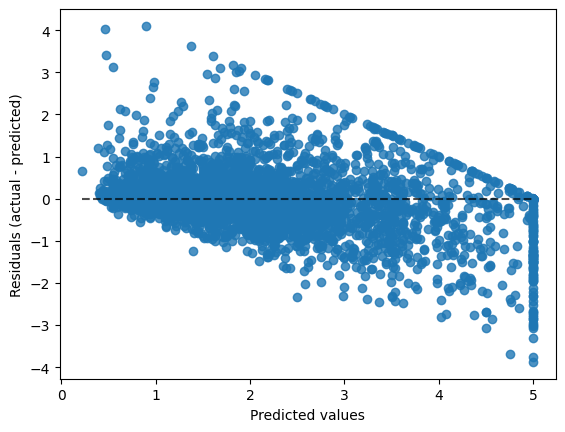

In [ ]:
# Visualise the result
error_plot_tree = PredictionErrorDisplay(
    y_true=y_test, y_pred=y_pred
)
_ = error_plot_tree.plot()

### Visualise Tree

Our next task is to visualise the tree itself. We do this with the [`plot_tree()`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) function.

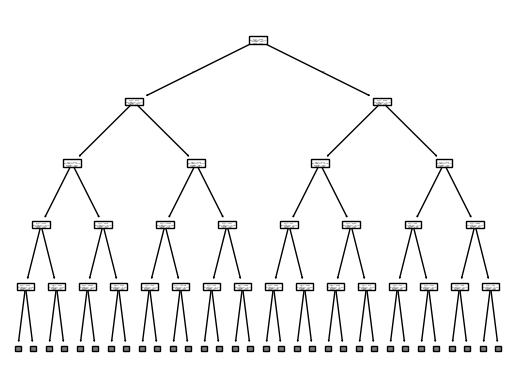

In [ ]:
plot = plot_tree(decision_tree=model_tree, max_depth=4)

## **Part 2: Bagged Tree (Random Forest)**

Now that we have successfully built and trained a model containing a single tree, we can now progress towards _ensemble_ models, which will allow us to build many different trees.

As we already know from our class content, the two main types of tree-based ensemble methods are Bootstrap Aggregation (aka 'Bagging') and Boosted trees. We will begin firstly with the most well known and trusted Bagging algorithms called a Random Forest, and we will use the [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) class.

In [ ]:
# !TASK!
# Instantiate the `RandomForestRegressor()` class
model_forest = ...

In [ ]:
# !SOLUTION!
# Instantiate the `RandomForestRegressor()` class
model_forest = RandomForestRegressor(random_state=42)

In [ ]:
# !TASK!
# Train the RandomForestRegressor algorithm
...

In [ ]:
# !SOLUTION!
# Train the RandomForestRegressor algorithm
model_forest.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# !TASK!
# Predict on the X_test data
pred_forest = ...

In [ ]:
# !SOLUTION!
# Predict on the X_test data
pred_forest = model_forest.predict(X_test)

In [ ]:
# Quick check on the predicted values
display(
    pd.DataFrame(
        zip(y_test, pred_forest),
        columns=["actual", "predicted"],
    )
)

,actual,predicted
0,0.47700,0.509500
1,0.45800,0.741610
2,5.00001,4.923257
3,2.18600,2.529610
4,2.78000,2.273690
...,...,...
4123,2.63300,2.267210
4124,2.66800,1.993650
4125,5.00001,4.758219
4126,0.72300,0.714090


In [ ]:
# !TASK!
# Measure the performance of the model
mse_forest = ...
print(f"Mean Squared Error: {mse_forest}")

In [ ]:
# !SOLUTION!
# Measure the performance of the model
mse_forest = mean_squared_error(y_test, pred_forest)
print(f"Mean Squared Error: {mse_forest}")

Mean Squared Error: 0.2553684927247781


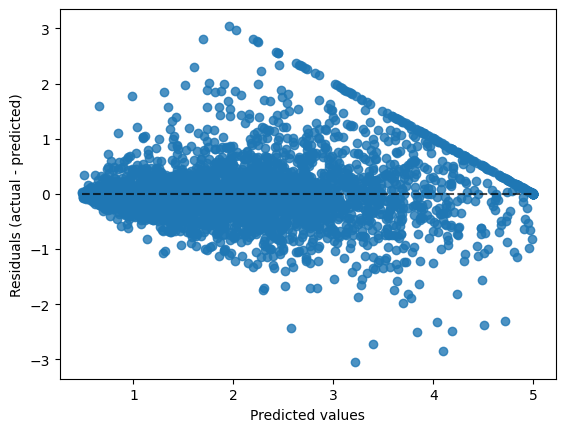

In [ ]:
# View the error plot
error_plot_forest = PredictionErrorDisplay(
    y_true=y_test, y_pred=pred_forest
)
_ = error_plot_forest.plot()

## **Part 3: Boosted**

The second algorithm we will review will be the Gradient Boosted algorithm, which we can implement by using the [`GradientBoostingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) class.

In [ ]:
# !TASK!
# Instantiate the `GradientBoostingRegressor()` class
model_boost = ...

In [ ]:
# !SOLUTION!
# Instantiate the `GradientBoostingRegressor()` class
model_boost = GradientBoostingRegressor(random_state=42)

In [ ]:
# !TASK!
# Train the GradientBoostingRegressor algorithm
...

In [ ]:
# !SOLUTION!
# Train the GradientBoostingRegressor algorithm
model_boost.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
# !TASK!
# Predict on the X_test data
pred_boost = ...

In [ ]:
# !SOLUTION!
# Predict on the X_test data
pred_boost = model_boost.predict(X_test)

In [ ]:
# Quick check on the predicted values
display(
    pd.DataFrame(
        zip(y_test, pred_boost),
        columns=["actual", "predicted"],
    )
)

,actual,predicted
0,0.47700,0.505188
1,0.45800,1.093346
2,5.00001,4.245710
3,2.18600,2.545174
4,2.78000,2.279103
...,...,...
4123,2.63300,2.099811
4124,2.66800,1.601285
4125,5.00001,4.681813
4126,0.72300,0.853295


In [ ]:
# !TASK!
# Measure the performance of the model
mse_boost = ...
print(f"Mean Squared Error: {mse_boost}")

In [ ]:
# !SOLUTION!
# Measure the performance of the model
mse_boost = mean_squared_error(y_test, pred_boost)
print(f"Mean Squared Error: {mse_boost}")

Mean Squared Error: 0.2939973248643864


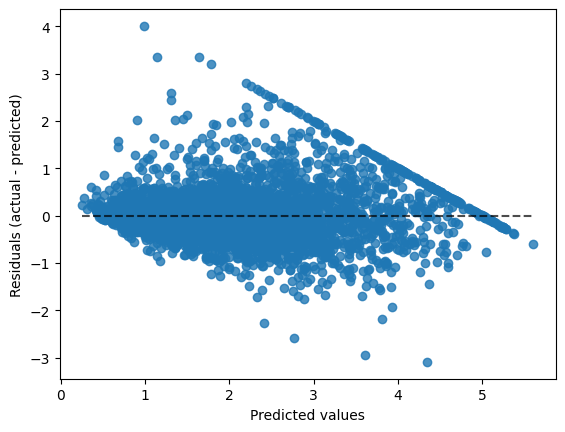

In [ ]:
# View the error plot
error_plot_boost = PredictionErrorDisplay(
    y_true=y_test, y_pred=pred_boost
)
_ = error_plot_boost.plot()

## **Comparison**

As can be seen by the below comparison of all three methods, the Bagged and Boosted algorithms are superior to the single tree method, with the Random Forest algorithm edging ahead of the Gradient Boosted algorithm just slightly.

In [ ]:
print(f"{mse_tree=}")
print(f"{mse_forest=}")
print(f"{mse_boost=}")

mse_tree=0.495235205629094
mse_forest=0.2553684927247781
mse_boost=0.2939973248643864


#Reflection

The above results show the mse values for three tree-based algorithms.
*   Analyse the results and determine which algorithm performed best.
*   Explain your reasoning and discuss the implications of the MSE values.



# Enter your answer here

# Submission
When you are ready to submit please go to `File` -> `Print` -> `Print PDF` and then upload and submit in the Campus Online.

Please save your file to GitHub via: `File` -> `Save a copy in GitHub`